In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from loader_cleaner import load_csv,  remove_duplicates, missing_values, convert_to_datetime
from plots import plot_distribution, plot_target_relationship
from feature_engineering_utils import ip_to_int, add_time_features, time_since_signup
from feature_engineering_utils import add_transaction_counts, encode_categorical, scale_numerical


In [4]:
df = load_csv('../data/processed/df_fraud_known_countries.csv')
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73036 entries, 0 to 73035
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         73036 non-null  int64  
 1   signup_time     73036 non-null  object 
 2   purchase_time   73036 non-null  object 
 3   purchase_value  73036 non-null  int64  
 4   device_id       73036 non-null  object 
 5   source          73036 non-null  object 
 6   browser         73036 non-null  object 
 7   sex             73036 non-null  object 
 8   age             73036 non-null  int64  
 9   ip_address      73036 non-null  float64
 10  class           73036 non-null  int64  
 11  country         73036 non-null  object 
dtypes: float64(1), int64(4), object(7)
memory usage: 6.7+ MB


In [5]:
missing_values(df)
df.duplicated().sum()
df = remove_duplicates(df)

In [6]:
df = convert_to_datetime(df, ['signup_time', 'purchase_time'])


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73036 entries, 0 to 73035
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         73036 non-null  int64         
 1   signup_time     73036 non-null  datetime64[ns]
 2   purchase_time   73036 non-null  datetime64[ns]
 3   purchase_value  73036 non-null  int64         
 4   device_id       73036 non-null  object        
 5   source          73036 non-null  object        
 6   browser         73036 non-null  object        
 7   sex             73036 non-null  object        
 8   age             73036 non-null  int64         
 9   ip_address      73036 non-null  float64       
 10  class           73036 non-null  int64         
 11  country         73036 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(4), object(5)
memory usage: 6.7+ MB


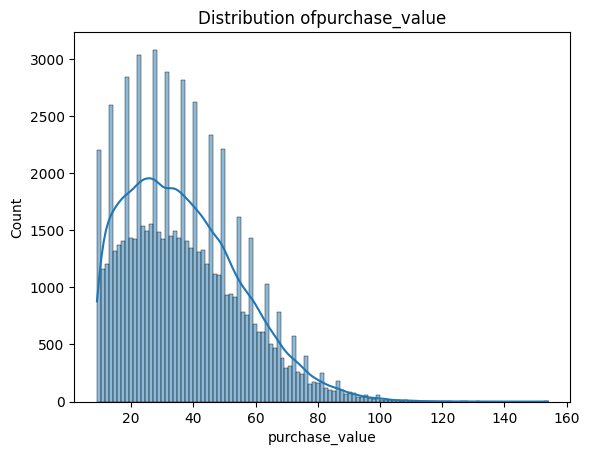

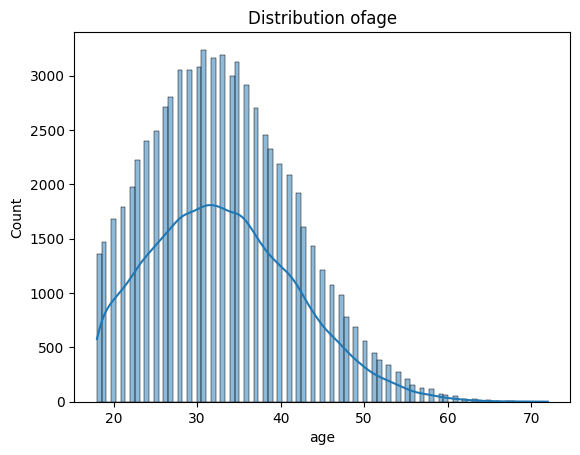

In [7]:
plot_distribution(df, "purchase_value")
plot_distribution(df, "age")

In [8]:
df['class'].value_counts(normalize=True) * 100

class
0    90.59368
1     9.40632
Name: proportion, dtype: float64

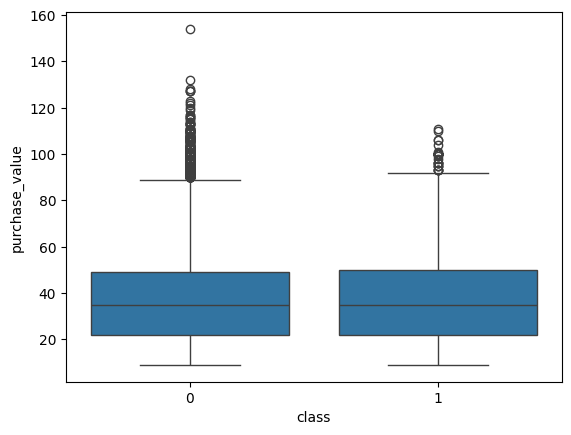

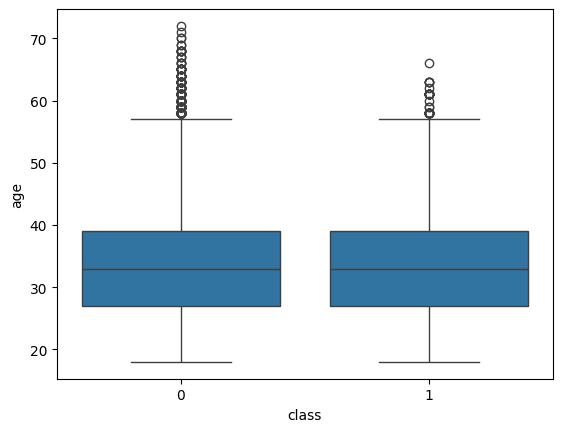

In [9]:
plot_target_relationship(df, 'purchase_value', 'class')

plot_target_relationship(df, 'age', 'class')

<Axes: xlabel='browser', ylabel='count'>

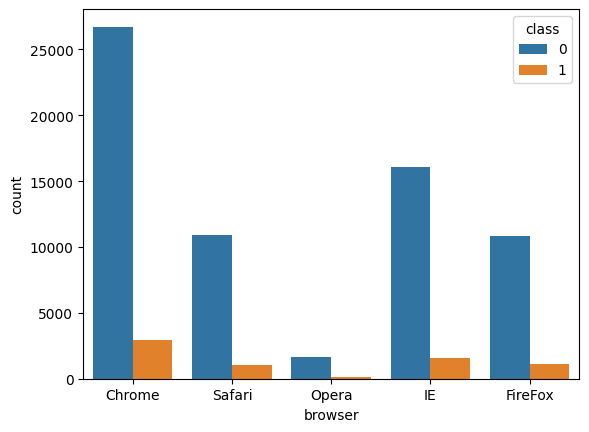

In [10]:
sns.countplot(x='browser', hue='class', data=df)

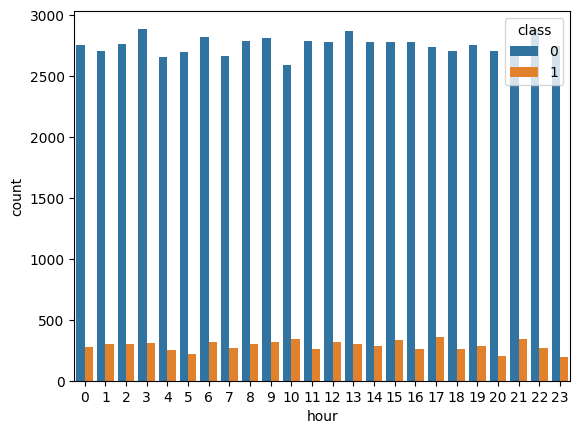

<Axes: xlabel='day', ylabel='count'>

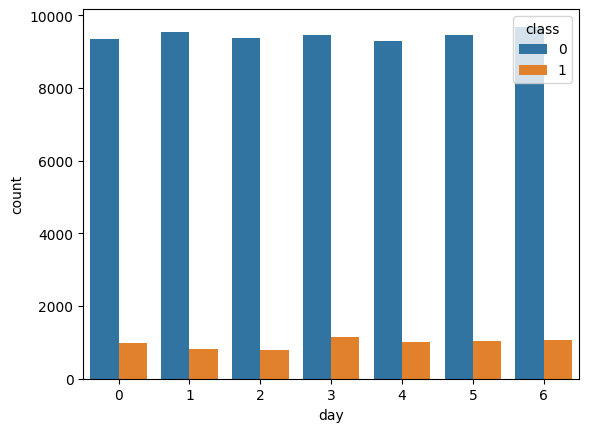

In [11]:
df['hour'] = df['purchase_time'].dt.hour
df['day'] = df['purchase_time'].dt.dayofweek
sns.countplot(x='hour', hue='class', data=df)
plt.show()
sns.countplot(x='day', hue='class', data=df)

In [12]:
df.to_csv("../data/processed/fraud_cleaned.csv", index=False)

In [ ]:
df = add_transaction_counts(df)

: 

In [14]:
df = add_time_features(df, 'purchase_time')
df = time_since_signup(df, 'signup_time', 'purchase_time')

In [15]:
num_cols = ['purchase_value','age','time_since_signup','txn_count','hour_of_day','day_of_week']
cat_cols = ['device_id','source','browser','sex','country']


df = scale_numerical(df, num_cols)
df = encode_categorical(df, cat_cols)